## KinTree (Kinetic Interaction Tree)
#### KinTREE is a decision tree based model that is able to caputre kinetic interaction rules from molecular dynamics simulations
Workflow Overview
1. Feature Extraction: Transform raw MD simulation trajectories into structured interaction data.
2. Model Training: Construct the KinTree to map the system's kinetic hierarchy.
3. Validation and Kinetic Analysis: Assess model robustness and statistical consistency. Calculate Mean First Passage Times (MFPT) and Transition Probability Matrices (TPM) to quantify state-to-state dynamics.
4. Structural Visualization:
    - Tree Construction: Visualize the hierarchical relationship between metastable states.
    - Cluster Networks: Map the specific interaction networks defining each structural cluster.

##### This notebook provides a general workflow for single-chain protein dynamics analysis.

### Step 1 Feature Extraction
This session preprocesses the data and prepares the input ready for the model. This includes:
1. **Sanity Checks**: Check whether the protontion states are correct, whether all residues have been defined by atom masks and stand amino acids list.
2. **Trajectory Alignment (Optional)**
3. **Trajectory Striding (Optional)**
2. **Calculation of the Contact map**
3. **Calculation of the Interaction network**
4. **Generate inputs**

In [1]:
import warnings
warnings.filterwarnings('ignore')
from Interaction_Detect import *
import MDAnalysis as mda
from MDAnalysis.analysis import align
from glob import glob
import torch

#### Critical Warning: Protonation States
Some molecular dynamics engines occasionally maintain standard residue names (e.g., **GLU**, **ASP**, or **CYS**) even after protonation changes. Since KinTree defines **atom masks** strictly based on these residue names, a mismatch will lead to incorrect interaction data.

Before proceeding, ensure your **protonation states align with your residue names.**

To facilitate this check, we provide the following checking function to validate your system. Things you should know for this function:
1. **Keep Hydrogens**: Your topology file must include hydrogen atoms
2. **Raw MD Output**: You can use the direct toplogy output from you simulation (including membrane components or solvent/salts). The function will filter for the relevant residues.

**Recommended Action**
Run the following cell to audit your topology. If the function flags a mismatch, you must either **update your residue names** in the .pdb/.gro file.

**Note that you might need to alter the function to suits your system**

In [213]:
def check_protonation_name_consistency(universe, selection="protein", verbose=True):
    """
    Check whether residue protonation state inferred from atom presence
    is consistent with residue name. Emits warnings (forced visible) and
    returns a list of mismatches.

    Parameters
    ----------
    universe : MDAnalysis.Universe
    selection : str
        Atom selection to scan (default "protein")
    verbose : bool
        Print a short summary + each mismatch line

    Returns
    -------
    mismatches : list[dict]
        Each dict contains segid, resid, resname, issue, details
    """
    ag = universe.select_atoms(selection)
    mismatches = []

    def record(res, issue, details):
        d = {
            "segid": str(res.segid),
            "resid": int(res.resid),
            "resname": str(res.resname),
            "issue": issue,
            "details": details,
        }
        mismatches.append(d)

    # Force warnings to show even in notebooks
    with warnings.catch_warnings():
        warnings.simplefilter("always", UserWarning)

        for res in ag.residues:
            resname = res.resname.strip()
            atom_names = {a.name.strip() for a in res.atoms}

            # ---- ASP / ASH: detect sidechain acidic H as HD1/HD2 (ignore HB*, HA, etc.) ----
            if resname in {"ASP", "ASH"}:
                has_sidechain_HD = any(n in atom_names for n in ("HD1", "HD2"))

                if resname == "ASP" and has_sidechain_HD:
                    msg = f"ASP has sidechain proton {sorted(set(atom_names)&{'HD1','HD2'})} but resname is ASP (expected ASH)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "ASP_named_but_protonated", msg)

                if resname == "ASH" and not has_sidechain_HD:
                    msg = "ASH has no sidechain proton (HD1/HD2 missing) but resname is ASH (expected ASP)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "ASH_named_but_deprotonated", msg)

            # ---- GLU / GLH: detect sidechain acidic H as HE1/HE2 ----
            if resname in {"GLU", "GLH"}:
                has_sidechain_HE = any(n in atom_names for n in ("HE1", "HE2"))

                if resname == "GLU" and has_sidechain_HE:
                    msg = f"GLU has sidechain proton {sorted(set(atom_names)&{'HE1','HE2'})} but resname is GLU (expected GLH)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "GLU_named_but_protonated", msg)

                if resname == "GLH" and not has_sidechain_HE:
                    msg = "GLH has no sidechain proton (HE1/HE2 missing) but resname is GLH (expected GLU)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "GLH_named_but_deprotonated", msg)

            # ---- Histidine: check tautomer consistency when named (skip plain HIS) ----
            if resname in {"HID", "HSD", "HIE", "HSE", "HIP", "HSP"}:
                has_HD1 = "HD1" in atom_names
                has_HE2 = "HE2" in atom_names

                expected = {
                    "HID": (True,  False),
                    "HSD": (True,  False),
                    "HIE": (False, True ),
                    "HSE": (False, True ),
                    "HIP": (True,  True ),
                    "HSP": (True,  True ),
                }[resname]

                found = (has_HD1, has_HE2)
                if found != expected:
                    msg = f"{resname} expected (HD1,HE2)={expected} but found {found}"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "HIS_tautomer_mismatch", msg)

            # ---- CYS / CYM: thiol proton HG ----
            # ---------- CYS / CYM / CYX ----------
            # ---------- CYS / CYM / CYX ----------
            if resname in {"CYS", "CYM", "CYX"}:
                has_thiol_H = any(a.name.startswith("HG") for a in res.atoms)

                if resname == "CYS" and not has_thiol_H:
                    msg = "CYS without thiol proton (may be CYM or CYX)"
                    warnings.warn(
                        f"{msg} (segid={res.segid}, resid={res.resid})",
                        UserWarning
                    )
                    record(res, "CYS_named_but_deprotonated", msg)

                if resname == "CYM" and has_thiol_H:
                    msg = "CYM with thiol proton (should be CYS)"
                    warnings.warn(
                        f"{msg} (segid={res.segid}, resid={res.resid})",
                        UserWarning
                    )
                    record(res, "CYM_named_but_protonated", msg)

                if resname == "CYX" and has_thiol_H:
                    msg = "CYX with thiol proton (disulfide cysteine should not have HG)"
                    warnings.warn(
                        f"{msg} (segid={res.segid}, resid={res.resid})",
                        UserWarning
                    )
                    record(res, "CYX_named_but_protonated", msg)



    if verbose:
        if mismatches:
            print(f"[protonation-name check] mismatches: {len(mismatches)}")
            for m in mismatches:
                print(f"  {m['segid']}:{m['resid']} {m['resname']} | {m['issue']} | {m['details']}")
        else:
            print("[protonation-name check] no mismatches found.")

    return mismatches

In [214]:
### example usage
u = mda.Universe('./data/g1_apo.pdb')
check_protonation_name_consistency(u)

[protonation-name check] mismatches: 10
  P0:50 HSE | HIS_tautomer_mismatch | HSE expected (HD1,HE2)=(False, True) but found (False, False)
  P0:133 CYS | CYS_named_but_deprotonated | CYS without thiol proton (may be CYM or CYX)
  P0:160 HSE | HIS_tautomer_mismatch | HSE expected (HD1,HE2)=(False, True) but found (False, False)
  P0:201 CYS | CYS_named_but_deprotonated | CYS without thiol proton (may be CYM or CYX)
  P0:207 CYS | CYS_named_but_deprotonated | CYS without thiol proton (may be CYM or CYX)
  P0:239 HSE | HIS_tautomer_mismatch | HSE expected (HD1,HE2)=(False, True) but found (False, False)
  P0:337 HSD | HIS_tautomer_mismatch | HSD expected (HD1,HE2)=(True, False) but found (False, False)
  P0:347 CYS | CYS_named_but_deprotonated | CYS without thiol proton (may be CYM or CYX)
  P0:421 CYS | CYS_named_but_deprotonated | CYS without thiol proton (may be CYM or CYX)
  P0:429 CYS | CYS_named_but_deprotonated | CYS without thiol proton (may be CYM or CYX)


/tmp/ipykernel_3894474/1107664268.py:86: UserWarning: HSE expected (HD1,HE2)=(False, True) but found (False, False) @ segid=P0, resid=50
  warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
/tmp/ipykernel_3894474/1107664268.py:97: UserWarning: CYS without thiol proton (may be CYM or CYX) (segid=P0, resid=133)
  warnings.warn(
/tmp/ipykernel_3894474/1107664268.py:86: UserWarning: HSE expected (HD1,HE2)=(False, True) but found (False, False) @ segid=P0, resid=160
  warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
/tmp/ipykernel_3894474/1107664268.py:97: UserWarning: CYS without thiol proton (may be CYM or CYX) (segid=P0, resid=201)
  warnings.warn(
/tmp/ipykernel_3894474/1107664268.py:97: UserWarning: CYS without thiol proton (may be CYM or CYX) (segid=P0, resid=207)
  warnings.warn(
/tmp/ipykernel_3894474/1107664268.py:86: UserWarning: HSE expected (HD1,HE2)=(False, True) but found (False, False) @ segid=P0, resid=239
  warnings.warn(f

[{'segid': 'P0',
  'resid': 50,
  'resname': 'HSE',
  'issue': 'HIS_tautomer_mismatch',
  'details': 'HSE expected (HD1,HE2)=(False, True) but found (False, False)'},
 {'segid': 'P0',
  'resid': 133,
  'resname': 'CYS',
  'issue': 'CYS_named_but_deprotonated',
  'details': 'CYS without thiol proton (may be CYM or CYX)'},
 {'segid': 'P0',
  'resid': 160,
  'resname': 'HSE',
  'issue': 'HIS_tautomer_mismatch',
  'details': 'HSE expected (HD1,HE2)=(False, True) but found (False, False)'},
 {'segid': 'P0',
  'resid': 201,
  'resname': 'CYS',
  'issue': 'CYS_named_but_deprotonated',
  'details': 'CYS without thiol proton (may be CYM or CYX)'},
 {'segid': 'P0',
  'resid': 207,
  'resname': 'CYS',
  'issue': 'CYS_named_but_deprotonated',
  'details': 'CYS without thiol proton (may be CYM or CYX)'},
 {'segid': 'P0',
  'resid': 239,
  'resname': 'HSE',
  'issue': 'HIS_tautomer_mismatch',
  'details': 'HSE expected (HD1,HE2)=(False, True) but found (False, False)'},
 {'segid': 'P0',
  'resid': 3

**Handling Protonation Mismatches**
If you see any mismatch in the previous cell, you must manually correct your topology with the expectd namings. Failure to do so will result in an inaccurate interaction detection.

**Step-by-Step Correction**
1. **Identify the Residue**: Note the residue ID and atom names flagged by the function. The residue ID provided by the function is the actualy ID in the pdb.
2. **Edit the Topology**: Open your topology file (e.g., .pdb, .gro, or .psf) in a text editor.
3. **Rename the Residue**: Locate the specific residue and change its name to the kinetically correct version.
    Example: If you have a deprotonated Cysteine involved in a disulfide bond, change CYS to CYX.
4. **Re-Verify**: Save the file and run the checking function again to confirm the error is resolved.

Note: If you only have a topology without hydrogen, then you have no choice but trust current protonation names.

In [215]:
u = mda.Universe('../data/g1_apo_clean.pdb')
check_protonation_name_consistency(u)

FileNotFoundError: [Errno 2] No such file or directory: '../data/g1_apo_clean.pdb'

#### Optional: Multi-Trajectory Alignment
The core KinTree workflow is optimized for a single trajectory. If your dataset contains **multiple trajectories**, you must **align them to a common reference frame** to ensure spatial consistency across all interaction data.

The following utility aligns each of your trajectories to a specified reference structure (e.g., a starting crystal structure or a representative frame).

In [ ]:
# --- Step 1. Specify paths ---
# Use the updated topology from here
topology = './data/g1_apo.pdb'
# Detect all trajectory files (can include subfolders)
trajectory_files = sorted(glob('./data/*/*.xtc'))  # or './Data/*.xtc' if flat folder

print(f"Detected {len(trajectory_files)} trajectories:")

In [ ]:
# Define the Reference structure
reference = mda.Universe(topology)

# List of short trajectories
traj_files = trajectory_files  # Replace with your file names

# Initialize writer for the combined trajectory
n_atoms = reference.atoms.n_atoms
writer = mda.Writer("./Aligned.xtc", n_atoms)

traj_lengths = []
for traj in traj_files:
    # Load trajectory
    u = mda.Universe(topology, traj)
    traj_lengths.append(len(u.trajectory))

    # Align trajectory to the reference
    ref_atoms = reference.select_atoms("protein")  # Adjust selection if needed
    mobile_atoms = u.select_atoms("protein")

    # Create alignment object
    alignment = align.AlignTraj(u, reference, select="protein", in_memory=True)
    alignment.run()

    # Write aligned frames to the combined trajectory
    for ts in u.trajectory:
        writer.write(u.atoms)

# Close the writer
writer.close()

print(f"Lengths: {traj_lengths}")
print(f"Total frames: {sum(traj_lengths)}")

**Preserving Trajectory Boundaries**\
When concatenating multiple simulation replicas, the trajectory length (frame count) for each individual run is stored as a metadata reference. This prevents the model from incorrectly assuming a physical transition exists between the last frame of "Trajectory A" and the first frame of "Trajectory B."

In [ ]:
with open('./traj_lengths.pkl', 'wb') as fp:
    pickle.dump(traj_lengths, fp)

#### Topology Validation and Atom Masking
Before running the interaction analysis, we must verify that every residue in your topology is recognized by the KinTree atom masks. This step ensures no chemical interactions are missed due to naming mismatches.

In [ ]:
topology = './data/g1_apo.pdb'
trajectory = './data/Aligned.xtc'

In [ ]:
validate_topology(topology,atom_masks)

If the function returns a list of "undefined" residues, do not be alarmed.\
    - **Engine-Specific Naming**: KinTree’s default masks use AMBER nomenclature and we have expanded it to suit other engines as well.\
    - **CHARMM/GROMOS Support**: If you are using a different force field, residues like Histidine might be named differently (e.g., HSD instead of HID).\
You can map unknown residue names to existing definitions without rewriting the underlying logic. This "aliasing" ensures the engine treats them identically.

In [ ]:
# atom_masks['HSD'] = atom_masks["HID"]
# atom_masks['HSE'] = atom_masks["HIE"]

You can save the atom mask for next time usage

In [ ]:
save_masks(atom_masks)

In [2]:
atom_masks = load_masks('./atom_masks.json')

Successfully loaded 29 masks from ./atom_masks.json


In [3]:
atom_masks

{'ARG': {'donors': ['NE', 'NH1', 'NH2', 'N'],
  'acceptors': ['O'],
  'cation': ['CZ', 'NH1', 'NH2']},
 'LYS': {'donors': ['NZ', 'N'], 'acceptors': ['O'], 'cation': ['NZ']},
 'HIS': {'donors': ['ND1', 'NE2', 'N'],
  'acceptors': ['ND1', 'NE2', 'O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2']},
 'HID': {'donors': ['ND1', 'N'],
  'acceptors': ['NE2', 'O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2']},
 'HIE': {'donors': ['NE2', 'N'],
  'acceptors': ['ND1', 'O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2']},
 'HIP': {'donors': ['ND1', 'NE2', 'N'],
  'acceptors': ['O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2'],
  'cation': ['ND1', 'NE2']},
 'ASP': {'donors': ['N'],
  'acceptors': ['OD1', 'OD2', 'O'],
  'anion': ['OD1', 'OD2']},
 'ASH': {'donors': ['OD1', 'N'], 'acceptors': ['OD2', 'O']},
 'GLU': {'donors': ['N'],
  'acceptors': ['OE1', 'OE2', 'O'],
  'anion': ['OE1', 'OE2']},
 'GLH': {'donors': ['OE1', 'N'], 'acceptors': ['OE2', 'O']},
 'ASN': {'donors': ['ND2', 'N'

In [ ]:
for res in list(atom_masks.keys()):
    # Iterate over copy of keys so we can delete while iterating
    for category in list(atom_masks[res].keys()):
        if not atom_masks[res][category]:  # Checks if list is empty []
            del atom_masks[res][category]  # Remove the key entirely

print("Atom masks cleaned: Empty categories removed.")

After mapping your force-field-specific residues, you must add them to the STANDARD_AMINO_ACIDS list.

This step is critical because the KinTree engine uses this list to identify protein backbone atoms. By default, the model filters out backbone-backbone interactions, as these are often ubiquitous and less "kinetically sensitive" than the side-chain interactions that drive specific conformational transitions.

In [ ]:
# Check the current standard amino acid
STANDARD_AMINO_ACIDS

In [ ]:
# Update if you have defined any amino acid names (like HSD)
# Just add to the set directly
# STANDARD_AMINO_ACIDS.add("HSD")
# STANDARD_AMINO_ACIDS.add("HSE")
# STANDARD_AMINO_ACIDS

**Essential! Check again moving forward**

In [ ]:
validate_topology(topology,atom_masks)

#### Optional: Striding Long Trajectories
For systems with high atom counts or long simulation times, striding the trajectory can significantly accelerate the interaction detection and model training phases without losing the essential kinetic landscape.

In [ ]:
import MDAnalysis as mda
import pickle

# --- Inputs ---
topology = topology
trajectory = "./Aligned.xtc"
stride = 5

# --- Load original trajectory lengths ---
with open('./traj_lengths.pkl', 'rb') as fp:
    traj_lengths = pickle.load(fp)

# --- Create universe and writer ---
u = mda.Universe(topology, trajectory)

# --- Write strided trajectory ---
with mda.Writer("./Strided_MT1_prot.xtc", u.atoms.n_atoms) as W:
    for ts in u.trajectory[::stride]:
        W.write(u.atoms)

# --- Save new traj_lengths (just integer division) ---
traj_lengths_strided = [L // stride for L in traj_lengths]

with open("./traj_lengths_strided.pkl", "wb") as f:
    pickle.dump(traj_lengths_strided, f)

print("✅ Saved strided trajectory and 'traj_lengths_strided.pkl'")

In [ ]:
# --- Load current trajectory lengths ---
with open('./traj_lengths_strided.pkl', 'rb') as fp:
    traj_lengths = pickle.load(fp)

#### Calculation of Contact map and Interaction network
This session converts raw coordinates into a kinetic feature set by mapping residue-to-residue contacts.

1. **Benchmarking**: Determine the maximum batch size your hardware (GPU/RAM) can handle to optimize processing speed.

2. **Soft Contact Map**: Instead of binary cutoffs, we assign a continuous soft score to each pair. This captures subtle conformational fluctuations that rigid thresholds miss.

3. **Interaction Network**: Construct a weighted network using these scores. The previously defined atom_masks and STANDARD_AMINO_ACIDS are applied here to filter out backbone noise.

4. **Model Input**: Flatten the network tensors into a structured format.

In [ ]:
# Speicfy the path to your topology file and trajectory file
trajectory = "./data/Aligned.xtc"
u = mda.Universe(topology, trajectory)
n_frames = len(u.trajectory)

if n_frames != sum(traj_lengths):
    print(f"ERROR: Total frames in Aligned.xtc ({n_frames}) does not match "
          f"sum of individual traj lengths ({sum(traj_lengths)})!")
else:
    print(f"Frame count OK: {n_frames} frames total.")

In [ ]:
# Test the optimal batch size based on your resources
optimal_batch = find_max_batch_size(topology, trajectory, max_frames=n_frames)
print(f"Using batch size: {optimal_batch}")

In [ ]:
# Conduct the contact_map for the whole protein
# 40min for a 60000 frame trajecotry of a protein with 450 residues on AMD 5000 Series CPU
# --- Step 3. Compute contacts for all trajectories ---
# if you want to consider any water or ions. you need to specify their name in ligand_names variable!
os.makedirs('./data', exist_ok=True)
filtered_pairs_all = contact_map(
    topology=topology,
    trajectory=trajectory,
    batch_size=optimal_batch,
    outputpath='./data/contact_map_softcontacts.pkl'
)

print("\n✅ Contact map calculation complete.")
print("Trajectory lengths:", traj_lengths)
print("Total frames:", sum(traj_lengths))

In [ ]:
# Detect interactions based on the calculated contact map
# The customized thresholds is a txt file storing all the user defined threshold

# Define the thresholds content
# Parameters available for user design are:
# hydrogen bond distance threshold
# salt bridge distance threshold
# pi-pi interaction distance, angle, and slippage
# T shape interaction angle (distance and slippage are identical to pi-pi)
# cation-pi interaction distance and angle

# A sample is as follow, with default settings

thresholds_content = """# Interaction thresholds
hbond: 4.0
salt_bridge: 4.0
pi_pi: 6.0, 30.0, 3.5
T_shape: 30.0
cation_pi: 6.0, 30.0
"""

saving_path = "interaction_threshold.txt"

# Write to a txt file
with open(saving_path, "w") as f:
    f.write(thresholds_content)

print("interaction threshold file has been created!")

In [ ]:
with open('./data/contact_map_softcontacts.pkl', 'rb') as f:
    data = pickle.load(f)

_contact_map = data

print(f"Loaded {len(_contact_map)} frames from saved file.")
print(f"Trajectory lengths: {traj_lengths}")

In [ ]:
filtered_pairs_all = load_all_filtered_pairs(
    "./data/contact_map_softcontacts.pkl"
)

print(f"Loaded {len(filtered_pairs_all)} frames from saved file.")

In [ ]:
# Calculte the interaction from the calculated contact map
# at least 2h for a 60000 frame trajecotry of a protein with 450 residues on AMD 5000 Series CPU
interaction_detect_ = interaction_detect(topology, trajectory, filtered_pairs_all, customized_thresholds=saving_path,
                                         atom_masks=atom_masks,outputpath='./data/interaction.pkl')

print("\n✅ Interaction detection complete.")
print("Trajectory lengths:", traj_lengths)
print("Total frames:", sum(traj_lengths))

In [ ]:
# This would generate input without contacts
# One should see which works better
generate_interaction_input(
    interaction_detect_path="./data/interaction.pkl",
    outputpath="./data/interaction.pt"
)

In [ ]:
# Check the size of the save PyG file again
# Load the stored PyG file
data_dict = torch.load("./data/interaction.pt")

edge_index = data_dict["edge_index"]          # shape (2, N_edges)
edge_attr_all = data_dict["edge_attr_all"]    # list of [N_edges, F] tensors
interaction_types = data_dict["interaction_types"]

print("edge_index shape:", edge_index.shape)              # (2, N_edges)
print("num frames:", len(edge_attr_all))
print("edge_attr shape (first frame):", edge_attr_all[0].shape)  # (N_edges, F)
print("interaction types:", interaction_types)

### Step 2: Model Training
This session identifies the kinetically essential interactions that drive your system's transitions.

1. **Apply Hysteresis**: We use a dual-threshold filter to remove high-frequency "flickering" noise from transient contacts, ensuring only stable transitions are modeled.

2. **Filter Contact Map**: The soft contact map is refined to focus on essential residues, to reduce computation complexity and provide more detailed structural information

3. **Model Training**: The KinTree algorithm builds a hierarchical map of metastable states based on these filtered interaction networks.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
import random
from temporal_rule_tree import *
from msm_kinetics import *

In [2]:
# Force deterministic behavior
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

In [3]:
# Model training preparation
X, feature_names, feature_types = load_interaction_binary_pt(
    "./data/interaction.pt",
    use_types_separately=True,
    present_threshold=0.5
)
#contacts = load_contact_map_pkl('./data/contact_map_softcontacts.pkl')

In [4]:
with open('traj_lengths.pkl', mode='rb') as f:
    traj_lengths = pickle.load(f)

In [5]:
#traj_lengths

In [6]:
min_on, min_off, on_lengths, off_lengths = suggest_global_hysteresis_thresholds(
    X, traj_lengths=traj_lengths, on_percentile=95, off_percentile=95
)

[auto] Suggested thresholds: min_on=15, min_off=44
  (computed from 1687446 ON runs, 1694469 OFF runs)


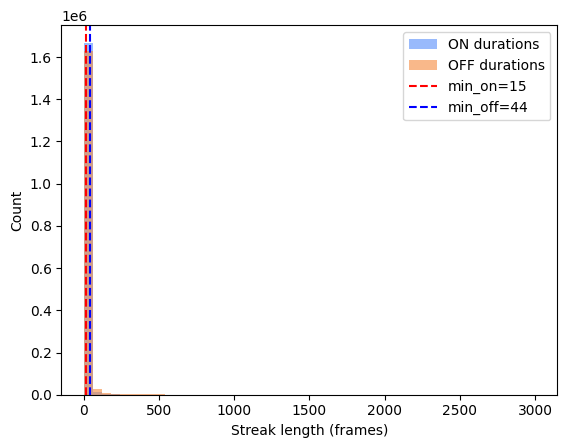

In [7]:
plt.hist(on_lengths, bins=50, alpha=0.6, label="ON durations")
plt.hist(off_lengths, bins=50, alpha=0.6, label="OFF durations")
plt.axvline(min_on, color='r', linestyle='--', label=f"min_on={min_on}")
plt.axvline(min_off, color='b', linestyle='--', label=f"min_off={min_off}")
plt.legend(); plt.xlabel("Streak length (frames)"); plt.ylabel("Count")
plt.show()

In [8]:
# --- τ prescan from debounced features (PCA + KMeans) ---
# 0) Debounce first (match the tree’s input)
# Increase min_on and min_off if the following test cannot pass the ck test
X_test = apply_hysteresis(X, min_on=15, min_off=15, traj_lengths=traj_lengths)

Applying hysteresis to all features (20 segments)...


In [9]:
T, F = X.shape

# Suggested starting parameters
short_on_thr = 2
short_off_thr = 4
pct_modified_thr = 0.15
min_raw_support = 0.02
max_occupancy_shift = 0.15
safe_occupancy_shift = 0.05
safe_helpful_ratio = 0.70
max_long_run_damage = 0.20
common_feature_raw_frac = 0.10

results = []

for f in range(F):
    raw = X[:, f].astype(int)
    smooth = X_test[:, f].astype(int)

    row = classify_feature_action(
        raw=raw,
        smooth=smooth,
        T=T,
        short_on_thr=short_on_thr,
        short_off_thr=short_off_thr,
        pct_modified_thr=pct_modified_thr,
        min_raw_support=min_raw_support,
        max_occupancy_shift=max_occupancy_shift,
        safe_occupancy_shift=safe_occupancy_shift,
        safe_helpful_ratio=safe_helpful_ratio,
        max_long_run_damage=max_long_run_damage,
        common_feature_raw_frac=common_feature_raw_frac,
    )

    row["feature_idx"] = f
    row["feature_name"] = feature_names[f]
    row["revert_old"] = row["pct_modified"] > pct_modified_thr
    results.append(row)

df = pd.DataFrame(results)

# =========================
# build final hybrid matrix
# =========================
X_hybrid_partial = X_test.copy().astype(int)

n_keep = 0
n_partial = 0
n_full = 0

for f in range(F):
    raw = X[:, f].astype(int)
    smooth = X_test[:, f].astype(int)

    action = df.loc[f, "action_new"]

    if action == "keep_smoothed":
        n_keep += 1
        continue

    elif action == "full_revert":
        X_hybrid_partial[:, f] = raw
        n_full += 1

    elif action == "partial_revert":
        revert_mask = make_partial_revert_mask(
            raw, smooth,
            short_on_thr=short_on_thr,
            short_off_thr=short_off_thr
        )
        X_hybrid_partial[revert_mask, f] = raw[revert_mask]
        n_partial += 1

    else:
        raise ValueError(f"Unknown action: {action}")

print("--- New hybrid summary ---")
print(f"keep_smoothed : {n_keep}")
print(f"partial_revert: {n_partial}")
print(f"full_revert   : {n_full}")

# Use this in downstream workflow
X = X_hybrid_partial

--- New hybrid summary ---
keep_smoothed : 4608
partial_revert: 95
full_revert   : 37

--- Specific Interaction Result ---
 raw_ON  smooth_ON  added_fake_ON  removed_true_ON  total_modified  pct_modified  raw_frac  smooth_frac  occupancy_shift  helpful_edit_ratio  long_run_damage     action_new                           reason_new  short_off_filled_frames  short_on_removed_frames  long_run_edited_frames  n_short_off_runs  n_short_off_runs_filled  n_short_on_runs  n_short_on_runs_removed  feature_idx  feature_name  revert_old
  29219      30218           9695             8696           18391      0.306517  0.486983     0.503633          0.01665            0.598336         0.401609 partial_revert common_feature_small_occupancy_shift                     7788                     3216                    7386              8146                     5151             5437                     2506         3565 273-379:hbond        True

--- Action counts ---
action_new
keep_smoothed     4608
part

In [ ]:
# Your residues of interest
important_residues = [21, 71, 128, 144, 152, 155, 159, 162,
                      273, 274, 278, 279, 282, 308, 324, 370, 371, 379, 403]

input_file = './data/contact_map_softcontacts.pkl'

# Run the loader
filtered_contacts = load_and_filter_contacts(input_file, important_residues)

# Verify
if filtered_contacts:
    print(f"Filtered contact count (frame 0): {len(filtered_contacts[0])}")
    # Example output: [(21, 150, 0.85), (21, 151, 0.44), ...]

In [ ]:
with open("./data/filtered_contacts.pkl", "wb") as f:
    pickle.dump(filtered_contacts, f)
print("Saved filtered contact map as filtered_contacts.pkl")

In [10]:
# Restore the data
with open("./data/filtered_contacts.pkl", "rb") as f:
    filtered_contacts = pickle.load(f)

print(f"Successfully loaded {len(filtered_contacts)} frames.")

Successfully loaded 60000 frames.


In [11]:
model = TemporalRuleTreeV6(
        lags=[5,10,15], # list of lag times
        alpha_vamp=0.5, # VAMP vs NMI weight
        min_pairs=3000, # minimum transition pairs per node
        min_leaf=3000, # minimum frames per leaf
        max_depth=5, # tree depth limit
        max_features_to_try=None, # try all features per split
        feature_types=feature_types, # feature type labels
        random_state=seed, # RNG seed
        # kinetic-aware parameters
        lag_mode="uniform", # emphasize the largest lag (40–60 → 60)
        tau_power=1.0, # used if lag_mode="power"
        lambda_row=0.7, # penalty weight for kinetically-similar children
        contact_frames=filtered_contacts,
        local_window=2,
        delta_mode='quantile',
        delta_quantile=0.6
        #delta_thresh=0.2
)

In [12]:
from temporal_rule_tree import seqsep_soft_weights
w_feat = seqsep_soft_weights(
    feature_names,
    min_sep=7,      # base threshold
    gamma=2.0,      # stronger penalty as sep gets smaller
    floor=0.15,     # never drop below 0.15 (to keep a faint chance)
    by_type={"hbond": 6, "salt_bridge": 5, "pi_pi": 8, "T_shape": 8, "cation_pi": 6}
)

In [13]:
# Set weights for different interactions
model.set_weights(feature_weights=w_feat,
                  type_weight_map={"hbond": 1.0,
                                   "salt_bridge": 1.5, 
                                   "pi_pi": 0.7, 
                                   "T_shape":0.5,
                                   "cation_pi":1.0})

In [14]:
# Train the model
model.fit(X, feature_names=feature_names, traj_lengths=traj_lengths)

Generating boundary-aware pairs for 20 trajectories.
[RankedGain D=0] 144-238:salt_bridge (VAMP=0.901, NMI=0.003) | RankScore=0.6798 * w=1.50 = Final=1.0197 | Best of 282 candidates.
  [Debug D=0] best=144-238:salt_bridge | VAMP_raw=0.901 NMI_raw=2.738e-03 sim_raw=0.053 | VAMP_pct=0.755 NMI_pct=0.947 sim_pct=0.245
[RankedGain D=1] 141-231:hbond (VAMP=0.967, NMI=0.008) | RankScore=0.9189 * w=1.00 = Final=0.9189 | Best of 190 candidates.
  [Debug D=1] best=141-231:hbond | VAMP_raw=0.967 NMI_raw=8.201e-03 sim_raw=0.016 | VAMP_pct=0.932 NMI_pct=0.995 sim_pct=0.063
[RankedGain D=2] 84-200:salt_bridge (VAMP=0.632, NMI=0.003) | RankScore=0.5000 * w=1.50 = Final=0.7500 | Best of 15 candidates.
  [Debug D=2] best=84-200:salt_bridge | VAMP_raw=0.632 NMI_raw=3.404e-03 sim_raw=0.226 | VAMP_pct=0.733 NMI_pct=0.733 sim_pct=0.333
[RankedGain D=2] 212-236:salt_bridge (VAMP=0.845, NMI=0.001) | RankScore=0.6226 * w=1.50 = Final=0.9339 | Best of 135 candidates.
[RankedGain D=3] 33-174:salt_bridge (VAMP=0

In [17]:
# Save tree
import os
os.makedirs('./output', exist_ok=True)
tree_dict = save_tree_json(model, "output/tree.json")

# Occupancy
occ = model.occupancy()

# Leaf assignments
labels = model.predict_leaf_ids(X)

Tree JSON saved to output/tree.json


In [18]:
# Check the output
print(f"T={X.shape[0]} frames, F={X.shape[1]} features, Leaves={occ.size}")
print("Top 10 leaf occupancies:", np.round(np.sort(occ)[::-1][:10], 4))
with open("output/tree.json") as f:
    tree = json.load(f)

T=60000 frames, F=4740 features, Leaves=12
Top 10 leaf occupancies: [0.188  0.1245 0.1152 0.0926 0.081  0.0764 0.0586 0.0559 0.053  0.0523]


In [19]:
# Features used in tree
split_features = collect_split_features(tree_dict, model)
print("Features driving splits:", split_features)

Features driving splits: ['144-238:salt_bridge', '141-231:hbond', '84-200:salt_bridge', '212-236:salt_bridge', '33-174:salt_bridge', '104-113:hbond', '25-285:hbond', '320-372:hbond', '163-301:hbond', '60-117:hbond', '33-174:salt_bridge']


In [20]:
def get_clean_mapping_dict(pdb_path, split_features):
    from Bio import PDB
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_path)

    # 1. Build the index-to-residue list
    pdb_residues = []
    for model in structure:
        for chain in model:
            c_id = chain.get_id().strip()
            prefix = f"{c_id}:" if c_id else ""
            for residue in chain:
                # FIX: Check if it's a chain residue (not water/ligand)
                # residue.get_id()[0] is the hetero-flag. ' ' means it's an ATOM record.
                if residue.get_id()[0] == ' ':
                    res_num = residue.get_id()[1]
                    pdb_residues.append(f"{prefix}{res_num}")

    # 2. Create the dictionary
    mapping_dict = {}
    for feat in split_features:
        try:
            parts = feat.replace(':', '-').split('-')
            idx1, idx2, interaction = int(parts[0]), int(parts[1]), parts[2]

            new_name = f"{pdb_residues[idx1]}-{pdb_residues[idx2]} ({interaction})"
            mapping_dict[feat] = new_name
        except Exception as e:
            mapping_dict[feat] = feat

    return mapping_dict

# --- Workflow ---

# 1. Generate the mapping
rename_map = get_clean_mapping_dict("./data/g1_apo.pdb", split_features)
rename_map

{'144-238:salt_bridge': '153-247 (salt_bridge)',
 '141-231:hbond': '150-240 (hbond)',
 '84-200:salt_bridge': '93-209 (salt_bridge)',
 '212-236:salt_bridge': '221-245 (salt_bridge)',
 '33-174:salt_bridge': '42-183 (salt_bridge)',
 '104-113:hbond': '113-122 (hbond)',
 '25-285:hbond': '34-294 (hbond)',
 '320-372:hbond': '329-381 (hbond)',
 '163-301:hbond': '172-310 (hbond)',
 '60-117:hbond': '69-126 (hbond)'}

### Step 3: Validate the Model
This session validates the KinTree using an Integrative Generalized Master Equation (IGME) framework. The transition information is only trustable when the model passes the CK test
1. **IGME Kinetic Lumping**: Aggregates rapidly interconverting microstates into distinct, metastable macrostates.
2. **CK test**: A rigorous validation step to ensure the model's transition probabilities are statistically consistent over multiple time scales
3. **Mean First Passage Time**: Calculates the average time required for the system to transition between specific macrostates
4. **Interaction Occupation**: Let you know which interaction is enriched in which state
5. **Essential Sanity Checks**: For model validity

#### IGME Kinetic Lumping

In [21]:
#taus = [1, 2, 3, 4, 5]   # example; choose what you like
#taus = 200 * taus
taus = np.arange(1,101)
taus = 5 * taus
# traj_lengths = [...]  # if you have multiple trajectories; else None
C_tau = collect_counts_multi_tau(labels, taus, traj_lengths=traj_lengths)

In [22]:
taus_sorted, T_series = build_tpm_series_from_counts(C_tau, alpha_smooth=0.5)

# choose fitting window in the *index* space (not physical τ)
best_igme = igme_fit_from_tpm_series(
    T_series,
    begin=2,        # ignore the very shortest lag if you want
    end=None,
    stride=1,
    min_its=0.0,
    max_its=1e18
)

Th = best_igme.Th   # long-time effective propagator used for lumping
A  = best_igme.A    # pre-factor (often not needed for lumping)

[IGME] best rmse = (0.0013573241783069827+3.720368740945993e-34j), window = [2, 71]


In [23]:
n_macrostates = 8  # choose a number you want to test

micro_to_macro = spectral_lumping_from_Th(Th, n_macrostates=n_macrostates,
                                          n_init=100, random_state=0)

macro_labels = collapse_labels(labels, micro_to_macro)

print("Macrostate occupancies:",
      np.bincount(macro_labels) / macro_labels.size)

Macrostate occupancies: [0.08101667 0.10803333 0.17378333 0.16905    0.18801667 0.05231667
 0.12453333 0.10325   ]


#### CK test

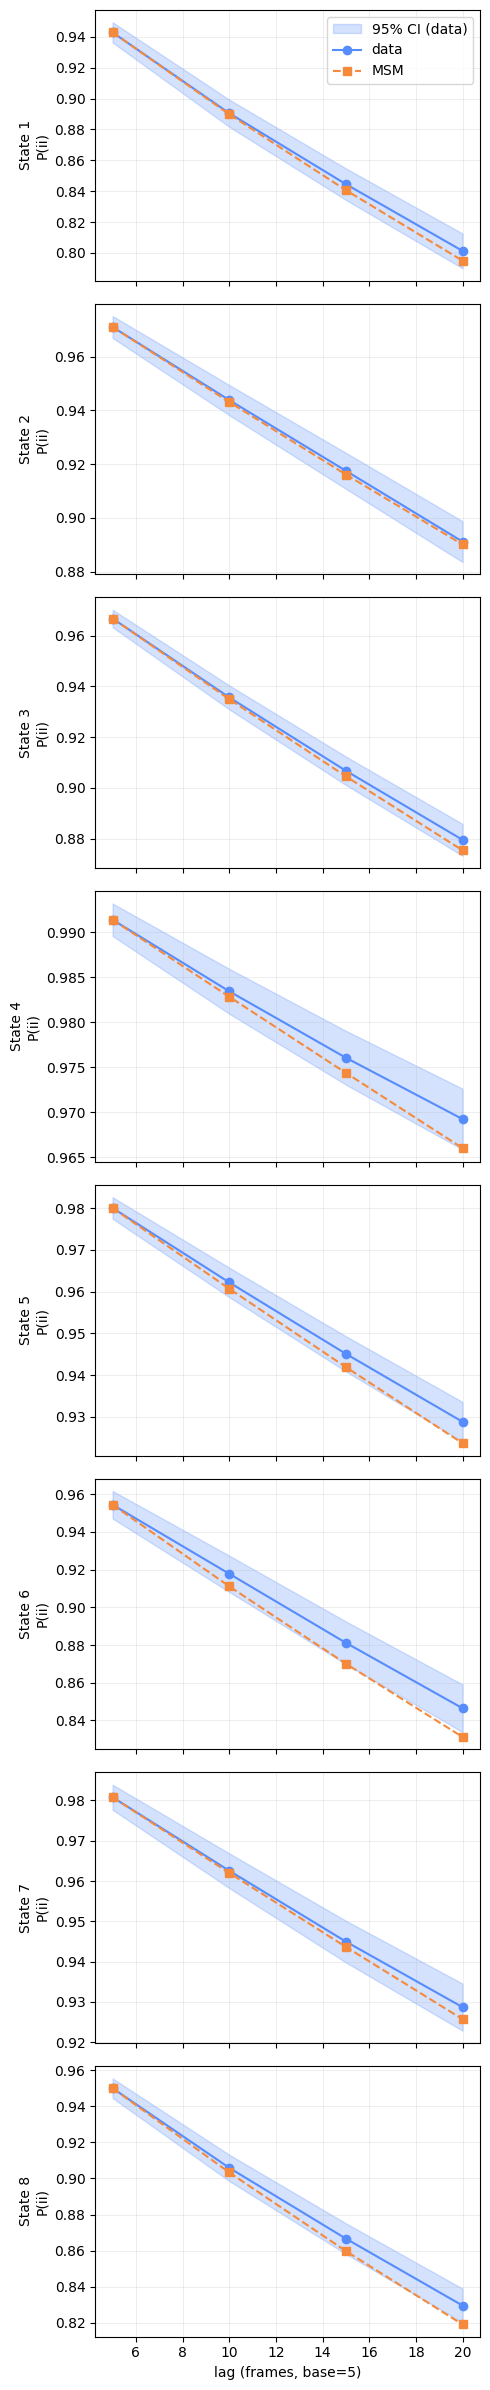

In [24]:
# 3) CK test on the macro MSM
tau0 = 5     # choose a base lag you like (should be among your taus)
k_list = [1, 2, 3, 4]

fig, axes = ck_test_macro(
    macro_labels, tau0=tau0, k_list=k_list,
    traj_lengths=traj_lengths, alpha_smooth=0.5
)

In [25]:
labels = clean_labels(labels)          # microstate per frame
macro_labels = clean_labels(macro_labels)  # macrostate per frame

In [26]:
micro_to_macro = derive_micro_to_macro(labels, macro_labels)

In [27]:
micro_to_macro
np.save('microtomacro.npy', micro_to_macro)

#### MFPT Calculation

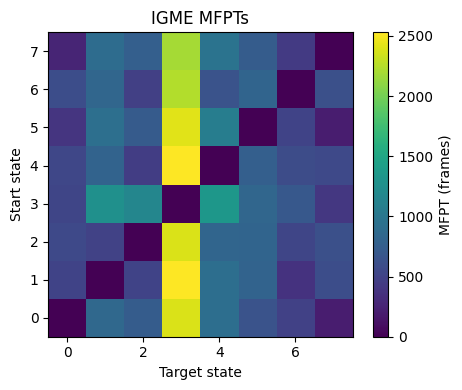

array([[   0.        ,  859.32567002,  733.66814458, 2384.41586988,
         914.44320818,  649.40135793,  491.91492308,  202.55457893],
       [ 509.48477663,    0.        ,  504.72717444, 2529.09132681,
         915.31756218,  804.65909842,  371.87383167,  600.56998244],
       [ 561.83147428,  499.34024167,    0.        , 2388.66518579,
         825.97163046,  812.77741388,  527.81974859,  619.31805792],
       [ 527.0406865 , 1270.58285729, 1161.12937625,    0.        ,
        1340.48997981,  834.80492889,  695.63164355,  406.0442803 ],
       [ 534.68956272,  804.75060165,  458.93318847, 2522.9667968 ,
           0.        ,  769.65135462,  587.63634111,  557.09590722],
       [ 388.96640742,  921.64865665,  729.07153185, 2412.79132835,
        1068.87481923,    0.        ,  512.68464934,  201.68635975],
       [ 598.80012911,  835.87945262,  476.1501106 , 2238.7343362 ,
         644.4489876 ,  819.40410576,    0.        ,  622.30663069],
       [ 258.04904845,  897.46922012,  76

In [28]:
pi_micro = get_stationary_from_igme(best_igme)
Th = np.array(best_igme.Th, dtype=float)

micro_to_macro = derive_micro_to_macro(labels, macro_labels)
T_macro = coarse_grain_transition_matrix(Th, pi_micro, micro_to_macro)

# --- NEW: project T_macro to a valid stochastic matrix ---
T = T_macro.copy()

# 1. clip negatives (interpret tiny negatives as numerical noise)
tol = 0.0  # or e.g. 1e-12 if you like
T[T < tol] = 0.0

# 2. renormalize rows
row_sums = T.sum(axis=1, keepdims=True)
zero_rows = (row_sums == 0).flatten()
if zero_rows.any():
    # make zero rows absorbing
    T[zero_rows, :] = 0.0
    T[zero_rows, zero_rows] = 1.0
    row_sums = T.sum(axis=1, keepdims=True)

T = T / row_sums

T_macro = T  # use this everywhere below

# now MFPT and anything else use a proper Markov matrix
T_mfpt = mfpt_matrix_igme(T_macro)
plot_mfpt_matrix_igme(T_mfpt)
T_mfpt

In [29]:
macro_labels

array([6, 6, 6, ..., 2, 2, 2], shape=(60000,))

In [30]:
print("Th shape:", Th.shape)
print("pi_micro length:", len(pi_micro))
print("micro_to_macro length:", len(micro_to_macro))
print("unique macro IDs:", np.unique(micro_to_macro))


Th shape: (12, 12)
pi_micro length: 12
micro_to_macro length: 12
unique macro IDs: [0 1 2 3 4 5 6 7]


In [31]:
probs = np.bincount(macro_labels) / macro_labels.size
R_kJ = 8.314462618e-3  # kJ/mol/K
T = 300.0
kBT = R_kJ * T

dF = -kBT * np.log(probs)

print("ΔF (kJ/mol):", np.round(dF, 3))

ΔF (kJ/mol): [6.269 5.551 4.365 4.434 4.169 7.359 5.196 5.664]


In [32]:
probs

array([0.08101667, 0.10803333, 0.17378333, 0.16905   , 0.18801667,
       0.05231667, 0.12453333, 0.10325   ])

#### Interaction Occupation
Note that the 'X' is the modified iput after applying hystersis. For accurate look up, please refer to the second dataframe calculated by 'X_raw'. The first dataframe serves as a sanity check to see whether the KinTree is splitting based on stable transitions rather than artificial noise or transient "flickering."

In [33]:
presence_df = macro_feature_presence(
    X,
    feature_names,
    macro_labels,          # from collapse_labels after spectral lumping
    set(split_features)    # features used by your tree
)
presence_df = presence_df.rename(columns=rename_map)
display(presence_df)

,34-294 (hbond),172-310 (hbond),329-381 (hbond),221-245 (salt_bridge),42-183 (salt_bridge),113-122 (hbond),153-247 (salt_bridge),93-209 (salt_bridge),150-240 (hbond),69-126 (hbond)
Macro 0,97.24,32.61,8.35,100.00,0.00,45.77,100.0,48.10,0.00,79.30
Macro 1,100.00,18.00,0.00,72.71,28.85,39.63,100.0,48.29,100.00,79.65
Macro 2,100.00,33.73,0.00,66.39,24.93,41.01,0.0,46.53,52.57,57.83
Macro 3,45.22,24.81,62.53,94.11,80.87,51.20,0.0,51.93,1.68,32.94
Macro 4,100.00,0.00,0.00,87.00,100.00,43.77,0.0,58.88,14.79,51.99
Macro 5,100.00,64.38,1.05,0.00,31.54,66.39,100.0,62.98,0.00,48.20
Macro 6,100.00,100.00,0.00,93.94,74.93,65.43,0.0,61.75,23.11,100.00
Macro 7,91.62,39.90,11.11,100.00,100.00,48.65,100.0,73.40,0.00,70.69


In [34]:
X_raw, feature_names, feature_types = load_interaction_binary_pt(
    "./data/interaction.pt",
    use_types_separately=True,
    present_threshold=0.5
)

In [35]:
presence_df = macro_feature_presence(
    X_raw,
    feature_names,
    macro_labels,          # from collapse_labels after spectral lumping
    set(split_features)    # features used by your tree
)
presence_df = presence_df.rename(columns=rename_map)
display(presence_df)

,34-294 (hbond),172-310 (hbond),329-381 (hbond),221-245 (salt_bridge),42-183 (salt_bridge),113-122 (hbond),153-247 (salt_bridge),93-209 (salt_bridge),150-240 (hbond),69-126 (hbond)
Macro 0,97.28,31.52,8.11,87.99,6.44,43.98,90.31,49.29,5.29,77.86
Macro 1,99.97,17.57,0.00,68.81,25.25,37.97,81.81,50.17,92.15,80.36
Macro 2,99.30,31.81,0.00,62.85,26.66,38.40,6.22,48.43,50.63,59.96
Macro 3,45.90,26.84,60.62,86.07,75.50,47.62,4.59,52.93,5.03,32.25
Macro 4,99.41,0.96,0.01,80.09,90.65,39.70,2.67,58.08,16.19,54.93
Macro 5,99.97,56.71,0.99,16.53,29.56,57.95,94.42,63.52,0.83,49.82
Macro 6,99.91,93.09,0.00,85.41,65.70,52.82,4.10,61.01,22.20,93.17
Macro 7,91.46,37.95,10.22,89.39,83.08,43.81,89.20,68.77,2.32,70.62


#### Sanity Checks
Before interpreting your results, we perform two critical checks to ensure the IGME model is mathematically and physically sound.

**Disconnected States**: We verify that the transition network is fully connected. If a state has no pathways to the rest of the system, it indicates insufficient sampling or a "trapped" microstate.

**Stationary Distribution (NaN Check)**: We audit the IGME results for NaN (Not a Number) values. A NaN in the stationary distribution typically means the transition matrix is non-ergodic or ill-conditioned, rendering the model invalid.

Note: If either check fails, you may need to increase your lag time or refine your microstate lumping to ensure a continuous kinetic landscape.

In [36]:
print("Any NaN in T_macro?", np.isnan(T_macro).any())
print("Any non-finite in T_macro?", ~np.isfinite(T_macro).all())


Any NaN in T_macro? False
Any non-finite in T_macro? False


In [37]:
# model stationary distribution
n_states = T_macro.shape[0]
pi = np.ones(n_states) / n_states
for _ in range(10000):
    pi_next = pi @ T_macro
    if np.linalg.norm(pi_next - pi, ord=1) < 1e-12:
        break
    pi = pi_next
pi /= pi.sum()

# empirical occupancy
occ = np.bincount(macro_labels, minlength=len(pi))
occ = occ / occ.sum()

print("Compare stationary vs. data occupancy:")
for i, (p, o) in enumerate(zip(pi, occ)):
    print(f"Macro {i}: π_model={p:.3f}, occ_data={o:.3f}")

# sanity check
if np.isnan(pi).any():
    raise ValueError("NaN detected in IGME stationary distribution — model invalid.")


Compare stationary vs. data occupancy:
Macro 0: π_model=0.092, occ_data=0.081
Macro 1: π_model=0.131, occ_data=0.108
Macro 2: π_model=0.147, occ_data=0.174
Macro 3: π_model=0.241, occ_data=0.169
Macro 4: π_model=0.167, occ_data=0.188
Macro 5: π_model=0.037, occ_data=0.052
Macro 6: π_model=0.079, occ_data=0.125
Macro 7: π_model=0.104, occ_data=0.103


### Step 4: Visualization
Here we provide Visualization functions to facilitate usage of our model. This includes:
1. Flux between macrostates
2. Three styles tree visualization
3. A function to extract representative frames from the trajectory for futher visualization
4. A ready to use pml (pymol input) file to directly open in pymol for high quality visualization output.
5. An interactive interface to visualize structure and the tree

#### Flux between macrostates

In [38]:
# Example usage (assuming source=1 and sink=5 based on your image)
# Note: Adjust indices to 1-based (e.g., source=0, sink=4)
start = 5
end = 4
net_flux, q = calculate_tpt_flux(T_macro, pi, start, end)
macro_list = np.unique(micro_to_macro).tolist()
# Usage:

paths = get_path_summary(net_flux, start, end, macro_list)
paths.sort(key=lambda x: x[0], reverse=True)

print("percentage       \tpath")
print("-" * 37)
for perc, p in paths:
    print(f"{perc:<18}\t {p}")

percentage       	path
-------------------------------------
0.1407959251342733	 [5, 7, 6, 4]
0.1080869039402085	 [5, 7, 6, 2, 4]


In [39]:
import plotly.graph_objects as go

# 1. Use the net_flux matrix we calculated earlier (TPT flux)
# Let's assume net_flux is your (n_macros x n_macros) matrix
# 'pi' is your stationary distribution
# 'source_idx' and 'sink_idx' are your start and end macros

source_nodes = []
target_nodes = []
flux_values = []
node_labels = [f"Macro {i+1}" for i in range(n_macrostates)]

# Filter out tiny values to keep the plot clean
threshold = net_flux.max() * 0.01

for i in range(n_macrostates):
    for j in range(n_macrostates):
        if net_flux[i, j] > threshold:
            source_nodes.append(i)
            target_nodes.append(j)
            flux_values.append(net_flux[i, j])

# 2. Dynamic Color Palette
# Using a slightly more professional "muted" palette for MD papers
colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#8AB17D', '#B5179E']
# Ensure we have enough colors by cycling if n_macros is large
node_colors = [colors[i % len(colors)] for i in range(n_macrostates)]

# 3. Create semi-transparent link colors
link_colors = []
for src in source_nodes:
    hex_col = node_colors[src].lstrip('#')
    rgb = tuple(int(hex_col[i:i+2], 16) for i in (0, 2, 4))
    link_colors.append(f"rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, 0.4)")

# 4. Build the Figure
fig = go.Figure(data=[go.Sankey(
    arrangement = "snap", # Automatically arranges nodes to show flow
    node=dict(
        pad=30,
        thickness=30,
        line=dict(color="black", width=1),
        label=node_labels,
        color=node_colors,
        # Adding occupancy to hover for extra context
        customdata=[f"{pi[i]*100:.1f}%" for i in range(n_macrostates)],
        hovertemplate='<b>%{label}</b><br>Stationary Occupancy: %{customdata}<extra></extra>'
    ),
    link=dict(
        source=source_nodes,
        target=target_nodes,
        value=flux_values,
        color=link_colors,
        hovertemplate='Path: %{source.label} → %{target.label}<br>Reactive Flux: %{value:.2e}<extra></extra>'
    )
)])

fig.update_layout(
    title=dict(
        text=f"Transition Path Flow: Macro {start} → Macro {end}",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=14),
    width=1000,
    height=600,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.show()

In [40]:
import plotly.graph_objects as go
import numpy as np

# Assuming net_flux, pi, n_macrostates, start, and end are already defined

source_nodes = []
target_nodes = []
flux_values = []
node_labels = [f"Macro {i+1}" for i in range(n_macrostates)]

# 1. Stricter Threshold to clean up the layout
max_flux = np.max(net_flux)
threshold = 0.15 * max_flux

for i in range(n_macrostates):
    for j in range(n_macrostates):
        if net_flux[i, j] > threshold:
            source_nodes.append(i)
            target_nodes.append(j)
            flux_values.append(net_flux[i, j])

# Muted color palette
colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#8AB17D', '#B5179E']
node_colors = [colors[i % len(colors)] for i in range(n_macrostates)]

# 2. Highlight the dominant path
link_colors = []
for src, val in zip(source_nodes, flux_values):
    hex_col = node_colors[src].lstrip('#')
    rgb = tuple(int(hex_col[i:i+2], 16) for i in (0, 2, 4))

    # If this link carries >80% of the max flux, make it highly opaque.
    # Otherwise, fade it out to keep the focus on the main pathway.
    if val >= 0.80 * max_flux:
        alpha = 0.85  # Dominant path (pops out)
    else:
        alpha = 0.20  # Minor paths (faded)

    link_colors.append(f"rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, {alpha})")

# 3. Build the Figure
fig = go.Figure(data=[go.Sankey(
    arrangement = "snap",
    node=dict(
        pad=40, # Increased padding to give nodes more breathing room
        thickness=30,
        line=dict(color="black", width=1),
        label=node_labels,
        color=node_colors,

        # ---------------------------------------------------------
        # THE FIX FOR UGLY LAYOUTS: MANUAL POSITIONING
        # Plotly accepts normalized coordinates (0.0 to 1.0).
        # Uncomment and adjust these arrays to strictly force node positions!
        # x=[0.05, 0.3, 0.6, 0.9], # Left-to-right positions for each macrostate
        # y=[0.5, 0.2, 0.8, 0.5],  # Top-to-bottom positions for each macrostate
        # ---------------------------------------------------------

        customdata=[f"{pi[i]*100:.1f}%" for i in range(n_macrostates)],
        hovertemplate='<b>%{label}</b><br>Stationary Occupancy: %{customdata}<extra></extra>'
    ),
    link=dict(
        source=source_nodes,
        target=target_nodes,
        value=flux_values,
        color=link_colors,
        hovertemplate='Path: %{source.label} → %{target.label}<br>Reactive Flux: %{value:.2e}<extra></extra>'
    )
)])

# 4. Larger Fonts and Presentation-Ready Layout
fig.update_layout(
    title=dict(
        text=f"Transition Path Flow: Macro {start} → Macro {end}",
        x=0.5,
        font=dict(size=26, family="Arial, sans-serif") # Increased title
    ),
    font=dict(size=18, family="Arial, sans-serif"), # Increased global font
    width=1000,
    height=650,
    margin=dict(l=50, r=50, t=90, b=50)
)

fig.show()

In [49]:
import plotly.graph_objects as go
import numpy as np

# Assuming net_flux, pi, n_macrostates, start, and end are already defined

source_nodes = []
target_nodes = []
flux_values = []
node_labels = [f"Macro {i+1}" for i in range(n_macrostates)]

# 1. Stricter Threshold
max_flux = np.max(net_flux)
threshold = 0.15 * max_flux

for i in range(n_macrostates):
    for j in range(n_macrostates):
        if net_flux[i, j] > threshold:
            source_nodes.append(i)
            target_nodes.append(j)
            flux_values.append(net_flux[i, j])

# Muted color palette for the nodes themselves
colors = ['#395176', '#90b1cf', '#bdb0ca', '#9295b7', '#F2EAE0', '#547792', '#C0E1D2', '#FFCEE3', '#DCCCAC']
node_colors = [colors[i % len(colors)] for i in range(n_macrostates)]

# 2. Hardcode the Dominant Pathway (6 -> 8 -> 7 -> 5)
# IMPORTANT: Adjust these numbers if your arrays are 0-indexed but your mental model is 1-indexed!
dominant_edges = [(5, 7), (7, 6), (6, 4)]

link_colors = []
for src, tgt in zip(source_nodes, target_nodes):
    # Check if the current link is part of our dominant pathway
    if (src, tgt) in dominant_edges:
        # Vibrant Red for the main path (high opacity)
        link_colors.append("#F9B2D7")
    else:
        # Muted light gray for all other flux (low opacity)
        link_colors.append("rgba(200, 200, 200, 0.25)")

# 3. Build the Figure
fig = go.Figure(data=[go.Sankey(
    arrangement = "snap",
    node=dict(
        pad=40,
        thickness=30,
        line=dict(color="black", width=1),
        label=node_labels,
        color=node_colors,
        customdata=[f"{probs[i]*100:.1f}%" for i in range(n_macrostates)],
        hovertemplate='<b>%{label}</b><br>Stationary Occupancy: %{customdata}<extra></extra>'
    ),
    link=dict(
        source=source_nodes,
        target=target_nodes,
        value=flux_values,
        color=link_colors,
        hovertemplate='Path: %{source.label} → %{target.label}<br>Reactive Flux: %{value:.2e}<extra></extra>'
    )
)])

# 4. Massively Increased Fonts
fig.update_layout(
    title=dict(
        text=f"Transition Path Flow: Dominant Pathway 6 → 8 → 7 → 5",
        x=0.5,
        font=dict(size=30, family="Arial, sans-serif") # Increased to 30
    ),
    font=dict(size=36, family="Arial, sans-serif"), # Global font increased to 22 for labels
    width=1100, # Widened slightly to accommodate larger labels
    height=700, # Heightened slightly
    margin=dict(l=50, r=50, t=100, b=50)
)

fig.show()

In [50]:
# 2. Save as a Vector PDF (Crisp text, no pixels)
#fig.write_image("output/tree_publication_quality.pdf", width=1500, height=600)

# 3. Save as a High-Res PNG (if you absolutely need an image)
fig.write_image("output/flux.png", width=1500, height=600, scale=4)

fig.write_html("output/flux.html")

# 4. Optional: Put the button back if you are still working in the notebook
# (Refer back to your original updatemenus code)

In [ ]:
import numpy as np
#import nxviz as nv # Optional, but standard NetworkX is fine here
import networkx as nx
import matplotlib.pyplot as plt

# ================================================================
# 1. SETTINGS & THRESHOLDING
# ================================================================
flux_threshold = 0.15 * np.max(net_flux)
G = nx.DiGraph()

# Add all nodes to keep them "permanent" even if isolated
for label in macro_list:
    G.add_node(label)

# Add ONLY edges that exceed the threshold
n_macros = net_flux.shape[0]
for i in range(n_macros):
    for j in range(n_macros):
        val = net_flux[i, j]
        if val > flux_threshold:
            u, v = macro_list[i], macro_list[j]
            G.add_edge(u, v, weight=val)

# ================================================================
# 2. IDENTIFY TOP PATH (From your get_path_summary output)
# ================================================================
# paths[0] is (percentage, path_list) -> paths[0][1] is [6, 4, 5]
top_path_nodes = paths[0][1]
top_path_edges = list(zip(top_path_nodes[:-1], top_path_nodes[1:]))

# NEW: Create a list of 1-based indices for the labels and title
top_path_1based_list = [int(n) + 1 for n in top_path_nodes]
top_path_str = " → ".join(map(str, top_path_1based_list))
# ================================================================
# 3. PLOTTING
# ================================================================
pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(9, 7))

# Mapping for the nodes in the graph
labels_1based = {node: str(int(node) + 1) for node in G.nodes()}

# Draw ALL Nodes
node_colors = []
for node in G.nodes():
    if node == macro_list[start]: node_colors.append("#2ecc71") # Source
    elif node == macro_list[end]: node_colors.append("#e74c3c")  # Sink
    else: node_colors.append("lightgray")

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)

# Ensure the labels on the nodes are 1-based
nx.draw_networkx_labels(G, pos, labels=labels_1based, font_weight="bold")

# Separate edges for styling
all_edges = list(G.edges())
# We only highlight edges that actually exist in the filtered graph G
highlight_edges = [e for e in top_path_edges if G.has_edge(*e)]
background_edges = [e for e in all_edges if e not in highlight_edges]

# Helper for width scaling
w_max = np.max(net_flux)
def get_w(val): return 1.0 + 7.0 * (val / w_max)

# Draw Background Edges (Gray/Transparent)
if background_edges:
    nx.draw_networkx_edges(
        G, pos, edgelist=background_edges,
        width=[get_w(G[u][v]['weight']) for u, v in background_edges],
        edge_color="gray", alpha=0.2, arrows=True,
        connectionstyle="arc3,rad=0.1", arrowstyle='-|>', arrowsize=15
    )

# Draw Top Path Edges (Red/Solid)
if highlight_edges:
    nx.draw_networkx_edges(
        G, pos, edgelist=highlight_edges,
        width=[get_w(G[u][v]['weight']) for u, v in highlight_edges],
        edge_color="red", alpha=1.0, arrows=True,
        connectionstyle="arc3,rad=0.1", arrowstyle='-|>', arrowsize=25
    )

# Edge Labels (Labels also obey the threshold since they are pulled from G)
edge_labels = {(u, v): f"{d['weight']:.2e}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,
    font_color="blue", font_size=12, rotate=True, label_pos=0.52,bbox=dict(alpha=0)
)

plt.title(f"A→B Flux (Threshold > {flux_threshold:.1e})\nHighlighted: {top_path_str}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig('output/Flux.png', dpi=600, transparent=True)
plt.show()

#### Tree Visualization

In [ ]:
import plotly.express as px

with open('output/tree.json', 'r') as f:
    tree_data = json.load(f)

unique_macros = np.unique(micro_to_macro)
colors_palette = px.colors.qualitative.Bold  # High contrast for papers
macro_color_map = {m: colors_palette[i % len(colors_palette)] for i, m in enumerate(unique_macros)}

In [220]:
def parse_node(node, parent_id=None, connection="ROOT"):
    node_id = str(id(node))
    val = node.get("n_frames", 1)

    # 1. Format the Connection Label (The decision made by the parent)
    path_info = ""
    if connection == "PRESENT":
        path_info = "<i>Yes:</i><br>"
    elif connection == "ABSENT":
        path_info = "<i>No:</i><br>"

    if not node.get("leaf"):
        raw_rule = node.get("rule", {}).get("name", "Split")
        rule_name = rename_map.get(raw_rule, raw_rule)
        display_label = f"{path_info}<b>{rule_name}?</b>"
        node_color = "rgb(245, 245, 245)"
    else:
        # Leaf nodes
        micro_id = node.get("leaf_id")
        macro_id = micro_to_macro[micro_id]

        # UPDATE: Add 1 here for 1-based indexing in the plot cells
        display_label = f"{path_info}<b>Macro {macro_id + 1}</b>"
        node_color = macro_color_map[macro_id]

    ids.append(node_id)
    labels.append(display_label)
    parents.append(parent_id)
    values.append(val)
    colors.append(node_color)

    if "left" in node:
        parse_node(node["left"], node_id, connection="PRESENT")
    if "right" in node:
        parse_node(node["right"], node_id, connection="ABSENT")

# Clear lists before re-parsing
ids, labels, parents, values, colors = [], [], [], [], []
parse_node(tree_data)

# 3. Create Icicle Plot
fig = go.Figure()

fig.add_trace(go.Icicle(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(colors=colors, line=dict(color='white', width=1.5)),
    tiling=dict(orientation='v'),
    pathbar=dict(visible=True) # Adds breadcrumbs at the top when you click into a node
))

# 4. Legend Traces (Unchanged)
for m in unique_macros:
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=12, color=macro_color_map[m], symbol='square'),
        showlegend=False,
        name=f"Macrostate {m+1}"
    ))

# 5. Final Styling & Custom Reset Button
fig.update_layout(
    title=dict(
        text="Structural Path to Macrostate Classification",
        y=0.95,           # Brings title down slightly
        x=0.05,
        xanchor='left'
    ),
    template="plotly_white",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    # REDUCED top margin from 120 to 60
    margin=dict(t=60, l=10, r=10, b=10),

    # updatemenus=[
    #     dict(
    #         type="buttons",
    #         direction="right",
    #         active=0,
    #         x=1,
    #         y=1.15, # MOVED DOWN from 1.3 to 1.1 (just above the plot)
    #         buttons=[
    #             dict(
    #                 label="Reset View",
    #                 method="restyle",
    #                 args=[{"level": [""], "root": [""]}]
    #             )
    #         ]
    #     )
    # ]
)

# 6. Show the figure while disabling the useless default modebar

fig.show(config={'displayModeBar': False})

In [221]:
# 2. Save as a Vector PDF (Crisp text, no pixels)
fig.write_image("output/tree_publication_quality.pdf", width=1500, height=600)

# 3. Save as a High-Res PNG (if you absolutely need an image)
fig.write_image("output/tree_high_res.png", width=1500, height=600, scale=4)

fig.write_html("output/tree_.html")

# 4. Optional: Put the button back if you are still working in the notebook
# (Refer back to your original updatemenus code)

In [218]:
import json
import plotly.graph_objects as go
import plotly.express as px

# --- Preparation ---
# 1. Assuming 'rename_map' and 'micro_to_macro' are defined from previous steps
# rename_map = get_clean_mapping_dict("your_structure.pdb", split_features)
unique_macros = np.sort(np.unique(micro_to_macro))
colors_palette = px.colors.qualitative.D3
macro_color_map = {m: colors_palette[i % len(colors_palette)] for i, m in enumerate(unique_macros)}

ids, labels, parents, values, colors = [], [], [], [], []

def parse_node(node, parent_id=None, connection="ROOT"):
    node_id = str(id(node))
    val = node.get("n_frames", 1)

    # 1. Fix the "If Yes/No" logic to refer to the branch taken
    path_info = ""
    if connection == "PRESENT":
        path_info = "<i>Yes:</i><br>"
    elif connection == "ABSENT":
        path_info = "<i>No:</i><br>"

    if not node.get("leaf"):
        # 2. Renumber the feature
        raw_rule = node.get("rule", {}).get("name", "Split")
        # Split across lines for better fit in boxes
        rule_name = rename_map.get(raw_rule, raw_rule)

        display_label = f"{path_info}<b>{rule_name}?</b>"
        # 3. Clean structural color (Light Grey for decision nodes)
        node_color = "rgb(240, 240, 240)"
    else:
        # Leaf nodes
        micro_id = node.get("leaf_id")
        macro_id = micro_to_macro[micro_id]
        display_label = f"{path_info}<b>Macro {macro_id+1}</b>"
        node_color = macro_color_map[macro_id]

    ids.append(node_id)
    labels.append(display_label)
    parents.append(parent_id)
    values.append(val)
    colors.append(node_color)

    if "left" in node:
        parse_node(node["left"], node_id, connection="PRESENT")
    if "right" in node:
        parse_node(node["right"], node_id, connection="ABSENT")

# Clear and parse
ids, labels, parents, values, colors = [], [], [], [], []
parse_node(tree_data)

# 4. Create the Treemap with larger font and crisp lines
fig = go.Figure(go.Treemap(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(
        colors=colors,
        line=dict(color='white', width=2)
    ),
    # Use 'textinfo' and 'textfont' to fix the small font issue
    textinfo="label",
    textfont=dict(size=18),
    hovertemplate='<b>%{label}</b><br>Frames: %{value}<extra></extra>'
))

fig.update_layout(
    title="Structural Hierarchy Treemap",
    template="plotly_white",
    margin=dict(t=50, l=10, r=10, b=10)
)

fig.show(config={'displayModeBar': False})

In [219]:
# 2. Save as a Vector PDF (Crisp text, no pixels)
fig.write_image("output/treemap.pdf", width=1500, height=600)

# 3. Save as a High-Res PNG (if you absolutely need an image)
fig.write_image("output/treemap.png", width=1500, height=600, scale=4)

fig.write_html("output/treemap.html")

# 4. Optional: Put the button back if you are still working in the notebook
# (Refer back to your original updatemenus code)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import networkx as nx
import itertools
from matplotlib.patches import Patch

# ---------- 1. Build the tree ----------
# Assuming rename_map is already created from the PDB file
# rename_map = get_clean_mapping_dict("structure.pdb", split_features)

def tree_to_graph(tree):
    G = nx.DiGraph()
    counter = itertools.count()

    def dfs(node):
        node_id = next(counter)
        is_leaf = node.get("leaf", False)

        if is_leaf:
            # Get Macrostate ID instead of just Leaf ID for better info
            m_id = micro_to_macro[node['leaf_id']]
            label = f"Macro {m_id}"
            polarity = None
        else:
            rule = node.get("rule", {})
            raw_name = rule.get("name", "split")

            # --- MAPPING BACK TO PDB INDEX ---
            # We look up the raw name in our dictionary
            label = rename_map.get(raw_name, raw_name)

            polarity = rule.get("polarity_left_is_present", 1)

        G.add_node(
            node_id,
            label=label,
            leaf=is_leaf,
            leaf_id=node.get("leaf_id", -1),
            polarity=polarity,
        )

        if not is_leaf:
            left = node.get("left")
            right = node.get("right")
            if left is not None:
                left_id = dfs(left)
                branch_label = "Yes" if polarity == 1 else "No"
                G.add_edge(node_id, left_id, branch=branch_label)
            if right is not None:
                right_id = dfs(right)
                branch_label = "No" if polarity == 1 else "Yes"
                G.add_edge(node_id, right_id, branch=branch_label)
        return node_id

    dfs(tree)
    return G


# ---------- 2. Layout ----------
def hierarchy_pos_lr(G, root=None, width=1.0, vert_gap=0.25, vert_loc=0, xcenter=0.5):
    if root is None:
        root = list(G.nodes)[0]
    children = list(G.successors(root))
    if not children:
        return {root: (vert_loc, xcenter)}
    dx = width / len(children)
    nextx = xcenter - width / 2 - dx / 2
    pos = {root: (vert_loc, xcenter)}
    for child in children:
        nextx += dx
        pos.update(
            hierarchy_pos_lr(
                G,
                child,
                width=dx,
                vert_gap=vert_gap,
                vert_loc=vert_loc + vert_gap,
                xcenter=nextx,
            )
        )
    return pos

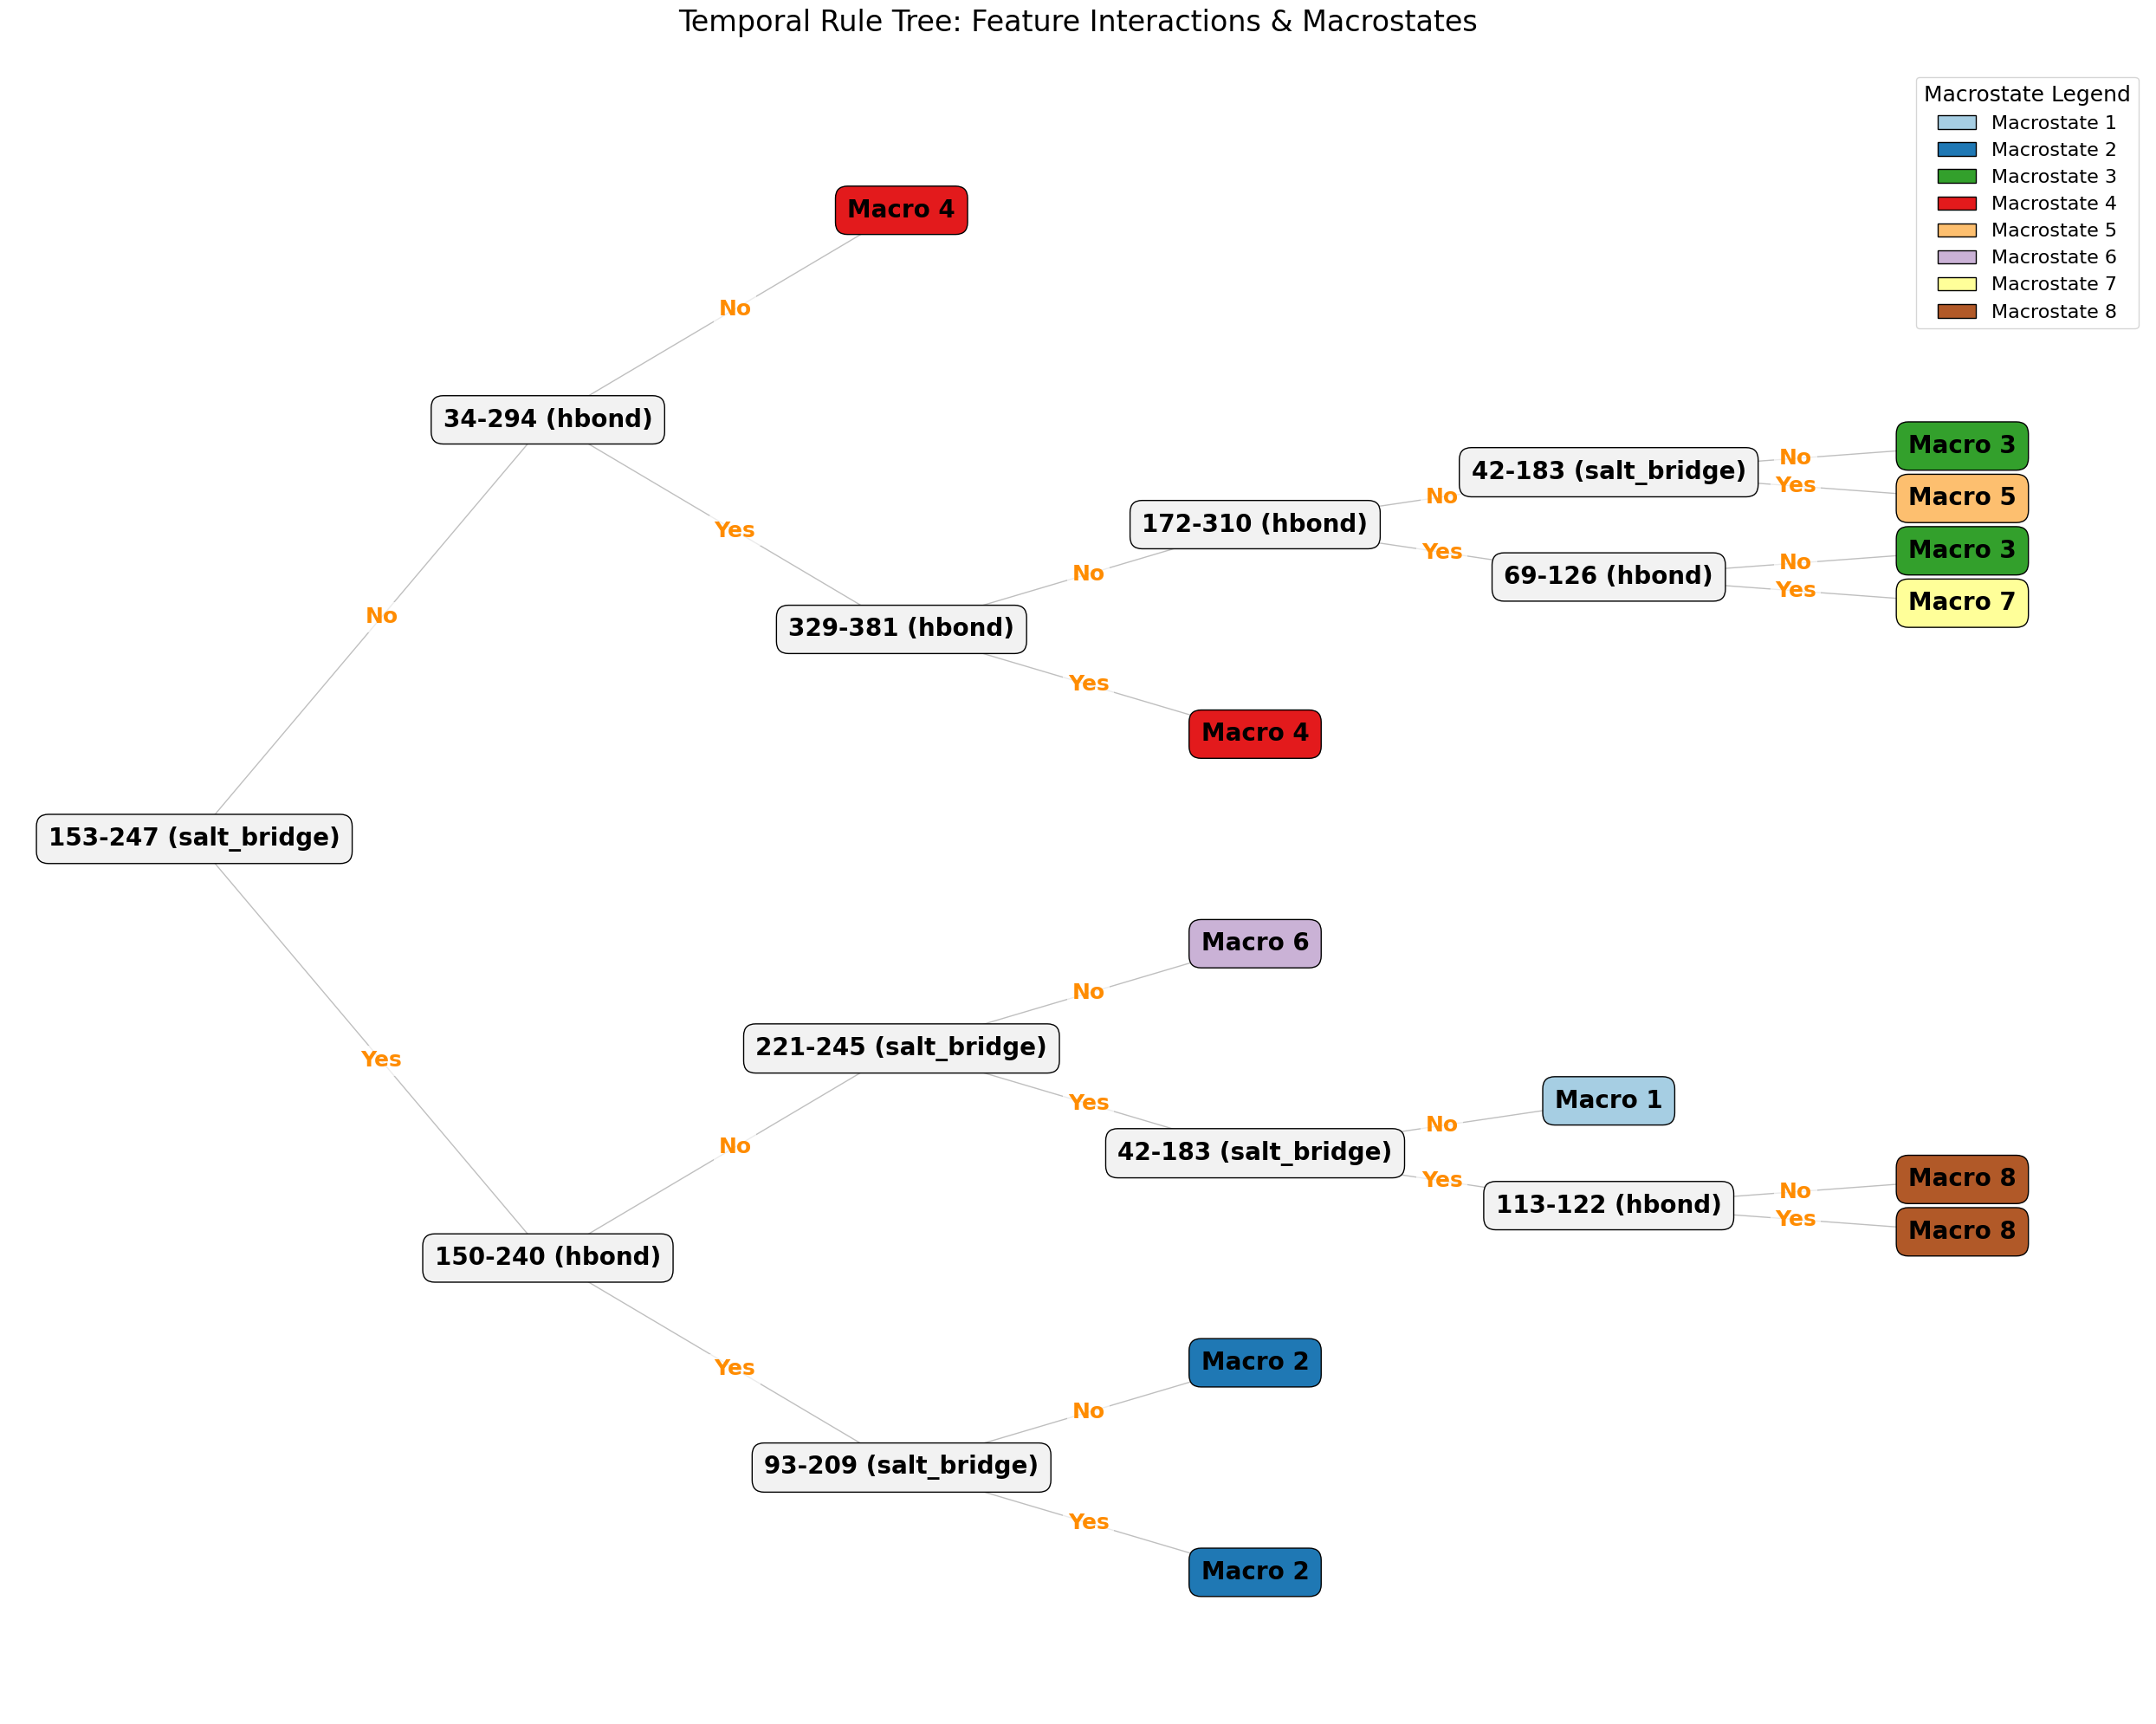

In [222]:
G = tree_to_graph(tree_dict)

z_micro2macro = micro_to_macro
n_macros = int(np.max(z_micro2macro)) + 1
cmap = cm.get_cmap("Paired", n_macros)

node_colors = []
for n, d in G.nodes(data=True):
    if d["leaf"]:
        macro_id = int(z_micro2macro[d["leaf_id"]])
        node_colors.append(cmap(macro_id))
    else:
        node_colors.append((0.8, 0.8, 0.8, 1.0))

# ---------- 4. Refined Plotting ----------
fig, ax = plt.subplots(figsize=(25, 20))
pos = hierarchy_pos_lr(G, width=5.0, vert_gap=0.3) # Increased width/gap for rectangles

# Draw edges first
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=15, edge_color="gray", alpha=0.5)

# Draw rectangular nodes with labels
for node, (x, y) in pos.items():
    data = G.nodes[node]

    # --- UPDATE START: Handle 1-based labeling ---
    if data["leaf"]:
        macro_id = int(micro_to_macro[data["leaf_id"]])
        facecolor = cmap(macro_id)
        # Force the label to be 1-based regardless of what's in the data dict
        display_label = f"Macro {macro_id + 1}"
    else:
        facecolor = (0.95, 0.95, 0.95)
        display_label = data["label"] # Keep "Rule?" labels as they are
    # --- UPDATE END ---

    ax.text(x, y, display_label, # Use the new display_label variable
            size=20,
            fontweight='bold',
            va="center", ha="center",
            bbox=dict(boxstyle="round,pad=0.5",
                      facecolor=facecolor,
                      edgecolor='black',
                      alpha=1.0))

# Edge labels (Yes/No)
edge_labels = nx.get_edge_attributes(G, 'branch')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_color="darkorange",
    font_size=18, # Increased size
    font_weight='bold',
    rotate=False,
    label_pos=0.53,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

# ---------- 5. Legend & Formatting ----------
legend_elements = [
    Patch(facecolor=cmap(i), edgecolor='black', label=f"Macrostate {i+1}")
    for i in range(n_macros)
]
ax.legend(handles=legend_elements, title="Macrostate Legend", loc="upper right",
          fontsize=16, title_fontsize=18, frameon=True)

plt.title("Temporal Rule Tree: Feature Interactions & Macrostates", fontsize=24, pad=30)
plt.axis("off")
plt.tight_layout()
plt.savefig('output/tree.png', dpi=600)
plt.show()

#### Extract frames for visualization

In [ ]:
# Extract frames for visualization
rng = np.random.default_rng(seed=42)  # set seed for reproducibility

macro_labels = np.asarray(macro_labels)
unique_clusters = np.unique(macro_labels)

samples_per_cluster = 100
selected_frames = {}

for c in unique_clusters:
    frame_indices = np.where(macro_labels == c)[0]

    if len(frame_indices) < samples_per_cluster:
        raise ValueError(
            f"Cluster {c} has only {len(frame_indices)} frames, "
            f"cannot sample {samples_per_cluster}."
        )

    chosen = rng.choice(
        frame_indices,
        size=samples_per_cluster,
        replace=False
    )

    selected_frames[c] = np.sort(chosen)  # sorting is optional

In [ ]:
selected_frames

In [ ]:
trajectory = "./data/Aligned.xtc"
trajectory

In [ ]:
from MDAnalysis.coordinates.XTC import XTCWriter

u = mda.Universe(topology, trajectory)
for cluster_id, frames in selected_frames.items():
    out_xtc = f"./output/macro{cluster_id+1}_100frames.xtc"

    with XTCWriter(out_xtc, n_atoms=u.atoms.n_atoms) as W:
        for ts in u.trajectory[frames]:
            W.write(u.atoms)

    print(f"Wrote {out_xtc}")

#### Create PML file for pymol

In [ ]:
import re
from collections import defaultdict
import MDAnalysis as mda

FEATURE_RE = re.compile(r"^(?P<i>\d+)-(?P<j>\d+):(?P<itype>.+)$")

def _safe_token(x: str) -> str:
    return str(x).strip().replace(" ", "_").replace("-", "_").replace(":", "_")

def _resi_with_icode(res) -> str:
    """
    Return PyMOL-compatible resi string including insertion code if present.
    """
    resid = str(res.resid)
    icode = getattr(res, "icode", "")
    if icode and str(icode).strip() and str(icode).strip() != " ":
        return f"{resid}{str(icode).strip()}"
    return resid

def _infer_id_field(u: mda.Universe, prefer: str = "auto") -> str:
    """
    Decide whether to use PyMOL 'chain' or 'segi'.

    Heuristic:
    - If most chainIDs are 1 character -> chain
    - else if segids exist -> segi
    - else -> chain

    prefer can be: "auto", "chain", "segi"
    """
    prefer = (prefer or "auto").lower()
    if prefer in ("chain", "segi"):
        return prefer

    chain_vals = []
    segi_vals = []
    for res in u.residues:
        chain = getattr(res, "chainID", "") or ""
        segi  = getattr(res, "segid", "") or ""
        chain_vals.append(str(chain).strip())
        segi_vals.append(str(segi).strip())

    chain_nonempty = [c for c in chain_vals if c]
    segi_nonempty  = [s for s in segi_vals if s]

    if chain_nonempty:
        one_char_ratio = sum(len(c) == 1 for c in chain_nonempty) / len(chain_nonempty)
        if one_char_ratio >= 0.6:
            return "chain"

    if segi_nonempty:
        return "segi"

    return "chain"

def _sel_term(id_field: str, id_value: str, resi: str) -> str:
    """
    Build a PyMOL selection term for one residue:
      (chain A and resi 123)   or   (segi P0 and resi 123)
    If id_value is empty, fall back to (resi 123).
    """
    id_field = id_field.lower()
    id_value = str(id_value).strip()
    if id_value:
        return f"({id_field} {id_value} and resi {resi})"
    return f"(resi {resi})"

def _pml_name_for_feature(i: int, j: int, itype: str) -> str:
    return f"sf_{i}_{j}_{_safe_token(itype)}"

def write_tree_split_pml(
    split_features,
    pdb_path,
    out_pml="tree_split_pairs.pml",
    out_tsv="tree_split_pairs.tsv",
    object_name="holo",

    # Robustness / overrides
    id_field="auto",           # "auto" (recommended), or "chain", or "segi"

    # Visualization options
    label_pairs=True,          # label residues by resn+resi (PDB)
    label_field="CA",          # typically "CA" for protein; if missing, set to None to label all atoms
    color_by_type=True,
    background="white",
    cartoon_transparency=0.15,
    stick_radius=0.18,
):
    """
    Always selects BOTH endpoints (i and j) for every feature.
    Works for holo (protein-ligand) and apo (protein-protein) without any special cases.
    """

    u = mda.Universe(pdb_path)
    id_field_used = _infer_id_field(u, prefer=id_field)

    # Parse features into rows and group by type
    rows = []
    rows_by_type = defaultdict(list)

    for feat in split_features:
        m = FEATURE_RE.match(feat)
        if not m:
            raise ValueError(f"Unrecognized feature format: {feat} (expected 'i-j:type')")

        i = int(m.group("i"))
        j = int(m.group("j"))
        itype = m.group("itype").strip()

        rows.append((feat, i, j, itype))
        rows_by_type[itype].append((feat, i, j, itype))

    # Map residue index -> (id_value, resi, resn)
    def idx_to_terms(idx: int):
        res = u.residues[idx]
        if id_field_used == "chain":
            id_value = getattr(res, "chainID", "") or ""
        else:
            id_value = getattr(res, "segid", "") or ""
        id_value = str(id_value).strip()
        resi = _resi_with_icode(res)
        resn = str(res.resname).strip()
        return id_value, resi, resn

    # Write TSV legend (one line per feature, with both endpoints)
    with open(out_tsv, "w") as f:
        f.write(
            "feature\tinteraction\t"
            "model_i\tmodel_j\t"
            f"{id_field_used}_i\tresi_i\tresn_i\t"
            f"{id_field_used}_j\tresi_j\tresn_j\n"
        )
        for feat, i, j, itype in rows:
            i_id, i_resi, i_resn = idx_to_terms(i)
            j_id, j_resi, j_resn = idx_to_terms(j)
            f.write(
                f"{feat}\t{itype}\t"
                f"{i}\t{j}\t"
                f"{i_id}\t{i_resi}\t{i_resn}\t"
                f"{j_id}\t{j_resi}\t{j_resn}\n"
            )

    # Simple palette for interaction types (fallback is yellow)
    type_color_map = {
        "hbond": "yellow",
        "pi_pi": "cyan",
        "cation_pi": "magenta",
        "t-shape": "cyan",
        "t_shape": "cyan",
        "salt_bridge": "orange",
        "disulfide": "green",
    }

    # Emit PML
    all_feature_sel_names = []

    with open(out_pml, "w") as p:
        p.write("# Auto-generated PyMOL script: Tree split-driving pairs\n")
        p.write("reinitialize\n")
        p.write(f'load "{pdb_path}", {object_name}\n\n')

        p.write("hide everything\n")
        p.write(f"show cartoon, {object_name}\n")
        p.write(f"color gray80, {object_name}\n")
        p.write(f"set cartoon_transparency, {cartoon_transparency}\n\n")

        p.write("# Debug helpers (uncomment if selections are empty)\n")
        p.write(f"# print cmd.get_chains('{object_name}')\n")
        p.write(f"# print cmd.get_segis('{object_name}')\n")
        p.write(f"# iterate ({object_name} and name CA), print(chain, segi, resn, resi)\n\n")

        p.write(f"# Using PyMOL id_field = {id_field_used} (user requested: {id_field})\n\n")

        p.write("set label_size, 18\n")
        p.write("set label_color, black\n\n")

        # Per-feature selections grouped by interaction type
        for itype in sorted(rows_by_type.keys()):
            group_name = f"splits_{_safe_token(itype)}"
            p.write(f"# === {itype} ===\n")

            for feat, i, j, itype in rows_by_type[itype]:
                i_id, i_resi, _ = idx_to_terms(i)
                j_id, j_resi, _ = idx_to_terms(j)

                term_i = _sel_term(id_field_used, i_id, i_resi)
                term_j = _sel_term(id_field_used, j_id, j_resi)

                sel_name = _pml_name_for_feature(i, j, itype)
                all_feature_sel_names.append(sel_name)

                # Pair selection: always both endpoints
                p.write(f"select {sel_name}, ({term_i}) or ({term_j})\n")
                p.write(f"show sticks, {sel_name}\n")
                p.write(f"group {group_name}, {sel_name}\n")

                # Labels: resn+resi (PDB-based). Usually CA for protein.
                if label_pairs:
                    if label_field:
                        p.write(f'label {sel_name} and name {label_field}, "%s%s" % (resn, resi)\n')
                    else:
                        p.write(f'label {sel_name}, "%s%s" % (resn, resi)\n')

                p.write("\n")

            # Color the whole group by interaction type
            if color_by_type:
                key = itype.strip()
                key2 = key.lower().replace(" ", "_")
                color = type_color_map.get(key, type_color_map.get(key2, "yellow"))
                p.write(f"color {color}, {group_name}\n\n")

            p.write("\n")

        # Combined selection
        if all_feature_sel_names:
            p.write(f"select split_all, {' or '.join(all_feature_sel_names)}\n")
        else:
            p.write("select split_all, none\n")

        p.write(f"set stick_radius, {stick_radius}, split_all\n")
        p.write("zoom split_all, 12\n")
        p.write(f"bg_color {background}\n")

    return {
        "out_pml": out_pml,
        "out_tsv": out_tsv,
        "id_field_used": id_field_used,
        "n_features": len(rows),
    }

In [ ]:
info = write_tree_split_pml(
    split_features=split_features,
    pdb_path=topology,     # adjust if needed
    id_field="auto",           # or "segi" if your PDB uses segids like P0
    label_pairs=True,
    label_field="CA",          # if you want to label ligand too, set label_field=None (more clutter)
    color_by_type=True,
)

print("Generated:", info["out_pml"], info["out_tsv"])
print("Using id_field:", info["id_field_used"])
print("Features:", info["n_features"])

In [1]:
import numpy as np
test = np.load('./microtomacro.npy')

In [2]:
test

array([1, 1, 7, 7, 0, 5, 3, 6, 2, 4, 2, 3])